<a href="https://colab.research.google.com/github/dequiroz/1MTR53_RobIA/blob/main/03_Cinem%C3%A1tica_Robots_moviles/01_Modelo_uniciclo_taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://drive.google.com/uc?export=view&id=1FsTa2YzWwxY-HBkd2EOXAlkPJ1zpikWv" alt="drawing" width="150"/>


<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1VBn7nKlruxCPLHH_UuD8B2pkvKP7JLRd" alt="drawing" width="800"/>


</br>

<img src="https://drive.google.com/uc?export=view&id=1tpg1CJh4or-VMrY-Qip25hgedgwy1Y8-" alt="drawing" width="800"/>
</p>


# Simulación con modelo cinemático del Robot Uniciclo
* **Responsable del material:** Diego Quiroz Velasquez
* Pontificia Universidad Católica del Perú
* Sección Ingeniería Mecatrónica

---
> **Descripción:**
> Este archivo sirve como complemento práctico a los conceptos teóricos revisados en clase, enlazando la **Cinemática Directa** de un robot móvil uniciclo. Al finalizar este cuaderno, serás capaz de entender la aplicación de cinemática directa para simulaciones de movimiento.

<details>
<summary><b>Historial de Versiones del Documento (Hacer clic para desplegar)</b></summary>

<br>

| Versión | Fecha | Autor / Rol | Descripción del Cambio |
| :---: | :---: | :--- | :--- |
| **v1.0** | 11/09/2026 | Diego Quiroz | Estructuración inicial de cinemática para vehiculo diferencial. |

---
</details>
<br>

<img src="https://drive.google.com/uc?export=view&id=1vgFoFHEKMN0WcAFlKS2hPMg2KuBm3sp9" alt="drawing"/>

# Modelo cinemático del robot uniciclo

Este notebook implementa y simula el **modelo cinemático uniciclo**, presentado en la lectura previa a esta sesión:

$$
\dot{x} = v \cos\varphi \qquad \dot{y} = v \sin\varphi \qquad \dot{\varphi} = \omega
$$

Este sistema de ecuaciones diferenciales **no tiene solución cerrada** para perfiles arbitrarios de $v(t)$ y $\omega(t)$ (restricción no holonómica), por lo que se resuelve mediante **integración numérica**.

**Objetivo de la sesión:** que cada estudiante comprenda, mediante código, por qué la cinemática de un robot móvil con ruedas se expresa en velocidades y se integra en el tiempo, en lugar de calcularse con una fórmula algebraica directa como en un brazo manipulador.

> **Nota:** este notebook trabaja directamente con $v$ y $\omega$ (velocidad lineal y angular del robot). La próxima clase se derivarán las ecuaciones que relacionan $v$ y $\omega$ con las velocidades individuales de cada rueda, tanto para robots diferenciales como omnidireccionales.


## 1. Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True


## 2. Integración de Euler

La idea de la integración de Euler es simple: si conocemos la velocidad de un sistema en el instante $t$, podemos estimar su posición un pequeño instante $\Delta t$ después, asumiendo que la velocidad se mantiene aproximadamente constante durante ese intervalo:

$$
x_{k+1} = x_k + \dot{x}_k \cdot \Delta t
$$

Aplicando esto a las tres ecuaciones del modelo uniciclo, en cada paso $k$:

$$
x_{k+1} = x_k + v_k \cos(\varphi_k)\, \Delta t
$$
$$
y_{k+1} = y_k + v_k \sin(\varphi_k)\, \Delta t
$$
$$
\varphi_{k+1} = \varphi_k + \omega_k \, \Delta t
$$

Cuanto más pequeño es $\Delta t$, más precisa es la aproximación, pero se requieren más pasos de cálculo. Este mismo principio es la base de casi todos los simuladores de robots que verán en el curso.


## 3. Implementación del simulador

In [ ]:
def simular_uniciclo(v_func, omega_func, estado_inicial=(0.0, 0.0, 0.0),
                      dt=0.05, t_final=10.0):
    """
    Simula el modelo cinemático uniciclo mediante integración de Euler.

    Parámetros
    ----------
    v_func : function
        Función v(t) -> velocidad lineal comandada en el instante t [m/s]
    omega_func : function
        Función omega(t) -> velocidad angular comandada en el instante t [rad/s]
    estado_inicial : tuple (x0, y0, phi0)
        Pose inicial del robot [m, m, rad]
    dt : float
        Paso de integración [s]
    t_final : float
        Tiempo total de simulación [s]

    Retorna
    -------
    t : np.ndarray  - vector de tiempo
    x, y, phi : np.ndarray - trayectoria del robot
    v_hist, omega_hist : np.ndarray - velocidades comandadas en cada paso
    """
    n_pasos = int(t_final / dt)
    t = np.zeros(n_pasos + 1)
    x = np.zeros(n_pasos + 1)
    y = np.zeros(n_pasos + 1)
    phi = np.zeros(n_pasos + 1)
    v_hist = np.zeros(n_pasos + 1)
    omega_hist = np.zeros(n_pasos + 1)

    x[0], y[0], phi[0] = estado_inicial

    for k in range(n_pasos):
        v_k = v_func(t[k])
        omega_k = omega_func(t[k])

        v_hist[k] = v_k
        omega_hist[k] = omega_k

        # --- Ecuaciones cinemáticas del uniciclo (integración de Euler) ---
        x[k + 1] = x[k] + v_k * np.cos(phi[k]) * dt
        y[k + 1] = y[k] + v_k * np.sin(phi[k]) * dt
        phi[k + 1] = phi[k] + omega_k * dt
        # -------------------------------------------------------------

        t[k + 1] = t[k] + dt

    v_hist[-1] = v_func(t[-1])
    omega_hist[-1] = omega_func(t[-1])

    return t, x, y, phi, v_hist, omega_hist


## 4. Función auxiliar para graficar la trayectoria

In [ ]:
def graficar_trayectoria(x, y, phi, titulo="Trayectoria del robot", cada=10):
    fig, ax = plt.subplots()
    ax.plot(x, y, color="#1D6F8C", linewidth=2, label="Trayectoria")
    ax.plot(x[0], y[0], "o", color="#4C7A6B", markersize=9, label="Inicio")
    ax.plot(x[-1], y[-1], "s", color="#A0522D", markersize=9, label="Fin")

    # Flechas de orientación cada 'cada' pasos, para visualizar phi
    ax.quiver(x[::cada], y[::cada],
              np.cos(phi[::cada]), np.sin(phi[::cada]),
              color="#20242B", scale=25, width=0.004, alpha=0.6)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(titulo)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend()
    plt.show()


## 5. Ejemplo 1 — Línea recta

El caso más simple: velocidad lineal constante y velocidad angular nula ($\omega = 0$). Según el modelo, $\varphi$ nunca cambia, por lo que el robot debe desplazarse en línea recta en la dirección de su orientación inicial.

**Antes de ejecutar la celda:** ¿qué trayectoria esperas ver si $\varphi_0 = \pi/4$ en lugar de 0?


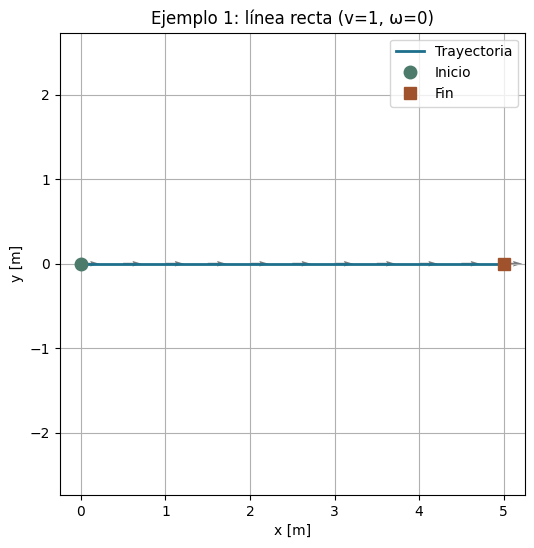

In [ ]:
v_recta = lambda t: 1.0        # velocidad lineal constante: 1 m/s
omega_recta = lambda t: 0.0    # sin rotación

t, x, y, phi, v_hist, omega_hist = simular_uniciclo(
    v_recta, omega_recta, estado_inicial=(0, 0, 0), dt=0.05, t_final=5.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 1: línea recta (v=1, ω=0)")


## 6. Ejemplo 2 — Trayectoria circular

Si $v$ y $\omega$ son ambas constantes y distintas de cero, el robot describe una circunferencia de radio $R = v / \omega$.

**Pregunta para el aula:** a partir del código, ¿qué le ocurre al radio de la trayectoria si se duplica $\omega$ manteniendo $v$ constante? Verifícalo modificando el valor antes de ejecutar la celda.


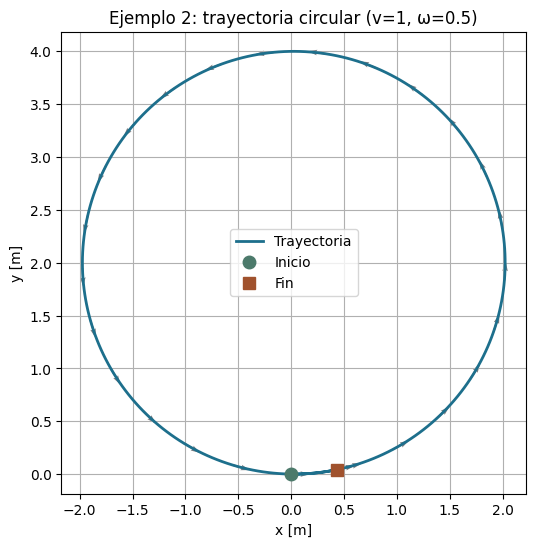

Radio teórico R = v/omega = 2.00 m


In [ ]:
v_circulo = lambda t: 1.0
omega_circulo = lambda t: 0.5   # rad/s constante -> radio teórico R = v/omega = 2 m

t, x, y, phi, v_hist, omega_hist = simular_uniciclo(
    v_circulo, omega_circulo, estado_inicial=(0, 0, 0), dt=0.05, t_final=13.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 2: trayectoria circular (v=1, ω=0.5)")

radio_teorico = 1.0 / 0.5
print(f"Radio teórico R = v/omega = {radio_teorico:.2f} m")


## 7. Ejemplo 3 — Trayectoria en "zigzag" con $\omega(t)$ variable

Aquí $\omega$ ya no es constante, sino una función del tiempo (una onda senoidal). Esto ilustra que el modelo admite **cualquier** perfil de velocidades, siempre que se integre numéricamente — no existe una fórmula cerrada equivalente.


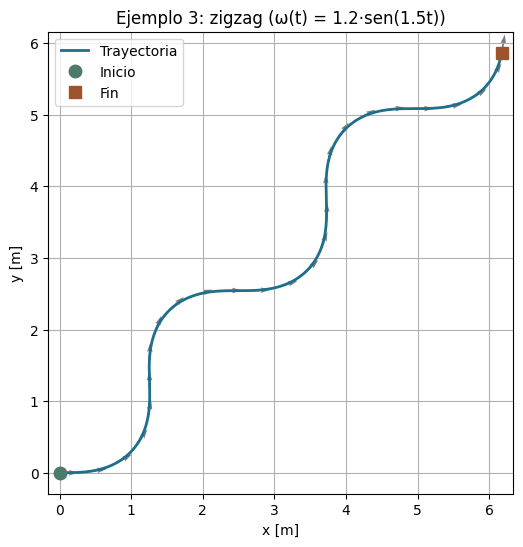

In [ ]:
v_zigzag = lambda t: 1.0
omega_zigzag = lambda t: 1.2 * np.sin(1.5 * t)   # oscila entre -1.2 y 1.2 rad/s

t, x, y, phi, v_hist, omega_hist = simular_uniciclo(
    v_zigzag, omega_zigzag, estado_inicial=(0, 0, 0), dt=0.02, t_final=10.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 3: zigzag (ω(t) = 1.2·sen(1.5t))", cada=20)


## 8. Ejemplo 4 — Maniobra por tramos (girar en el propio eje)

Un robot diferencial puede girar sobre su propio eje haciendo $v = 0$ y $\omega \neq 0$ (ver lectura previa, sección 6.2). El siguiente ejemplo combina tramos de avance recto con tramos de giro en el sitio, para trazar un cuadrado — la misma lógica que usarías para programar un recorrido punto a punto.


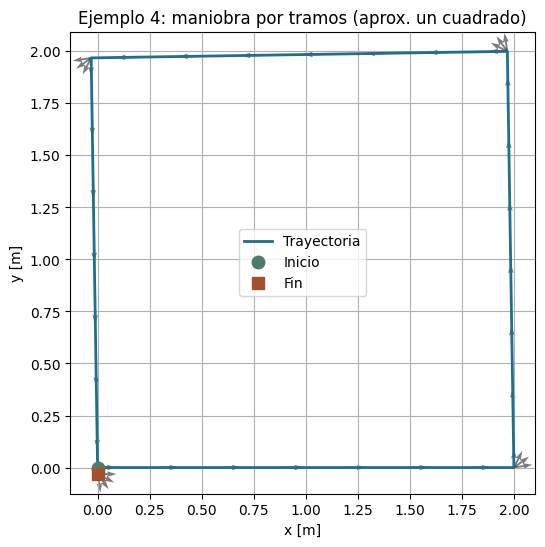

In [ ]:
def v_cuadrado(t):
    # Avanza durante 2 s, luego pausa 1 s (mientras gira), en un ciclo de 3 s
    fase = t % 3.0
    return 1.0 if fase < 2.0 else 0.0

def omega_cuadrado(t):
    # Gira 90° (pi/2 rad) en 1 s, solo durante la fase de pausa
    fase = t % 3.0
    return (np.pi / 2) if fase >= 2.0 else 0.0

t, x, y, phi, v_hist, omega_hist = simular_uniciclo(
    v_cuadrado, omega_cuadrado, estado_inicial=(0, 0, 0), dt=0.01, t_final=12.0
)

graficar_trayectoria(x, y, phi, titulo="Ejemplo 4: maniobra por tramos (aprox. un cuadrado)", cada=30)


## 9. Ejercicios propuestos

Resuelve los siguientes ejercicios modificando el código anterior. No hay una única celda "correcta": el objetivo es que experimentes con el modelo.

1. **Efecto del paso de integración.** Repite el Ejemplo 2 (círculo) con `dt = 0.5` en lugar de `0.05`. ¿La trayectoria sigue siendo un círculo suave? ¿Por qué la integración de Euler pierde precisión al aumentar `dt`?
2. **Radio de giro.** Genera tres trayectorias circulares con la misma `v` y tres valores distintos de `omega`. Verifica numéricamente (a partir de las coordenadas obtenidas) que el radio observado coincide con $R = v/\omega$.
3. **De cinemática diferencial a $v, \omega$.** Usando las ecuaciones de la lectura previa ($v = r(\dot\theta_r + \dot\theta_l)/2$, $\omega = r(\dot\theta_r - \dot\theta_l)/(2b)$), escribe una función `diferencial_a_uniciclo(theta_dot_r, theta_dot_l, r, b)` que reciba las velocidades angulares de ambas ruedas y retorne `(v, omega)`. Úsala junto con `simular_uniciclo` para simular un robot cuyas ruedas giran a `theta_dot_r = 4 rad/s` y `theta_dot_l = 2 rad/s`, con `r = 0.05 m` y `b = 0.15 m`.
4. **Discusión abierta (para la siguiente clase).** El ejercicio 3 asumió que ambas ruedas ruedan sin deslizar. ¿Qué ecuación de la lectura previa expresa esa condición para una sola rueda? ¿Qué tendría que cambiar en el modelo si una de las ruedas patinara?


v = 0.1500 m/s,  omega = 0.3333 rad/s


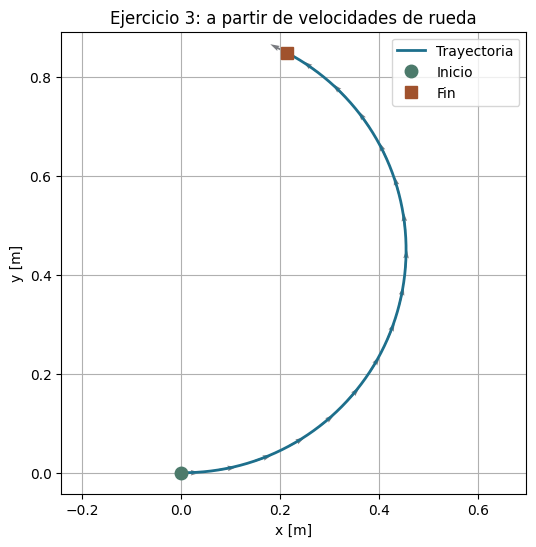

In [ ]:
# Espacio de trabajo para los ejercicios propuestos.
# Ejercicio 3 — completa la función:

def diferencial_a_uniciclo(theta_dot_r, theta_dot_l, r, b):
    """Convierte velocidades angulares de las ruedas de un robot diferencial
    en velocidad lineal (v) y angular (omega) del robot (modelo uniciclo)."""
    v = r * (theta_dot_r + theta_dot_l) / 2
    omega = r * (theta_dot_r - theta_dot_l) / (2 * b)
    return v, omega

# Prueba con los valores propuestos:
v_ej3, omega_ej3 = diferencial_a_uniciclo(theta_dot_r=4.0, theta_dot_l=2.0, r=0.05, b=0.15)
print(f"v = {v_ej3:.4f} m/s,  omega = {omega_ej3:.4f} rad/s")

t, x, y, phi, v_hist, omega_hist = simular_uniciclo(
    lambda t: v_ej3, lambda t: omega_ej3, estado_inicial=(0, 0, 0), dt=0.05, t_final=8.0
)
graficar_trayectoria(x, y, phi, titulo="Ejercicio 3: a partir de velocidades de rueda")
